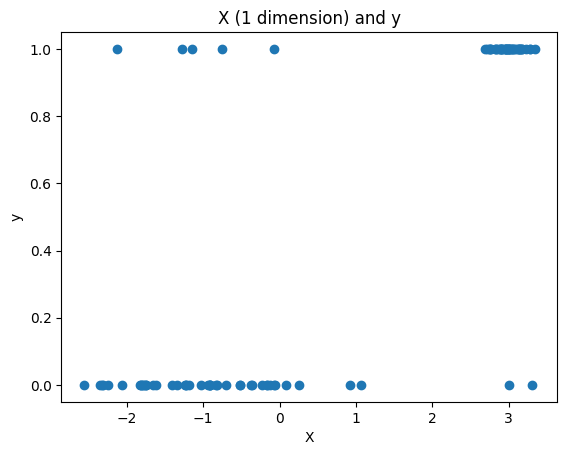

In [287]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

X,y = make_classification(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    weights=[0.5,0.5],
    flip_y=0.15,
    class_sep=2.0,
    hypercube=True,
    shift=1.0,
    scale=1.0,
    shuffle=True,
    random_state=88
)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("X (1 dimension) and y")
plt.show()

In [288]:
clf = LogisticRegression()
clf.fit(X, y)

print("intercept:", clf.intercept_)
print("coef:", clf.coef_)

intercept: [-0.98497516]
coef: [[1.18885765]]


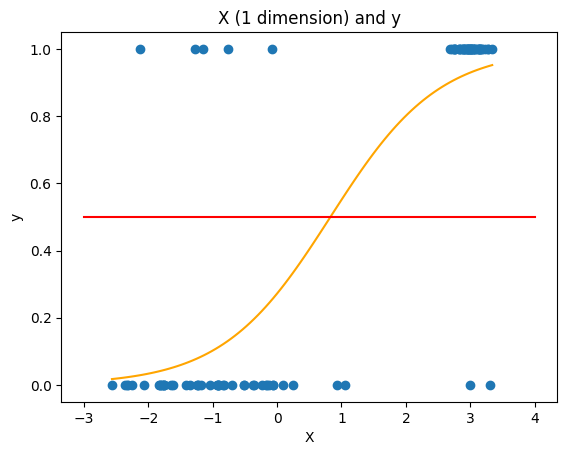

In [289]:
x_vals = np.linspace(X.min(), X.max(), 100)
y_sigmoid = 1 / (1 + np.exp(-(coef * x_vals + intercept)))

plt.scatter(X, y)
plt.plot(x_vals, y_sigmoid, color="orange")

plt.plot([-3.0, 4.0], [0.5, 0.5], color="red")

plt.xlabel("X")
plt.ylabel("y")
plt.title("X (1 dimension) and y")
plt.show()

In [290]:
def predict_probability(coefs, X):
    a, b = coefs
    return 1 / (1 + np.exp(-(a * X + b)))

manual_probs = predict_probability([coef, intercept], X[:,0])
sklearn_probs = clf.predict_proba(X)[:,1]

print(np.allclose(manual_probs, sklearn_probs))

True


In [291]:
def predict_class(coefs, X):
    probs = predict_probability(coefs, X)
    return (probs >= 0.5).astype(int)

print(np.all(predict_class([coef, intercept], X[:,0]) == clf.predict(X)))

True


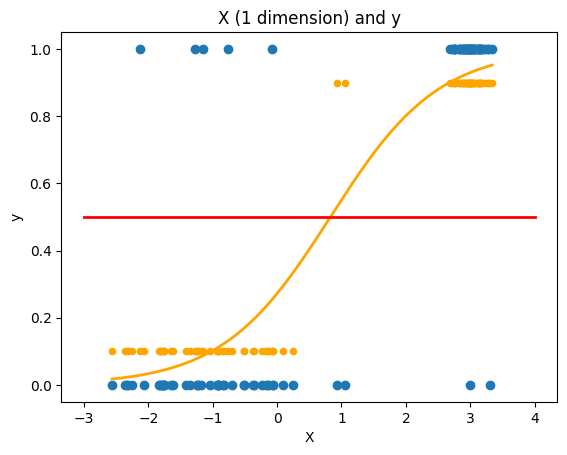

In [292]:
x_vals = np.linspace(X.min(), X.max(), 300)
y_sigmoid = 1 / (1 + np.exp(-(coef * x_vals + intercept)))

preds = predict_class([coef, intercept], X[:, 0])

plt.scatter(X[:, 0], y)
plt.plot(x_vals, y_sigmoid, color="orange", linewidth=2)

plt.scatter(X[:, 0], preds * 0.8 + 0.1, color="orange", s=20)
plt.plot([-3.0, 4.0], [0.5, 0.5], color="red", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title("X (1 dimension) and y")
plt.show()


[None, (-5.0, 5.0), (-5.0, 5.0), Text(0.5, 0, '$X_1$'), Text(0, 0.5, '$X_2$')]

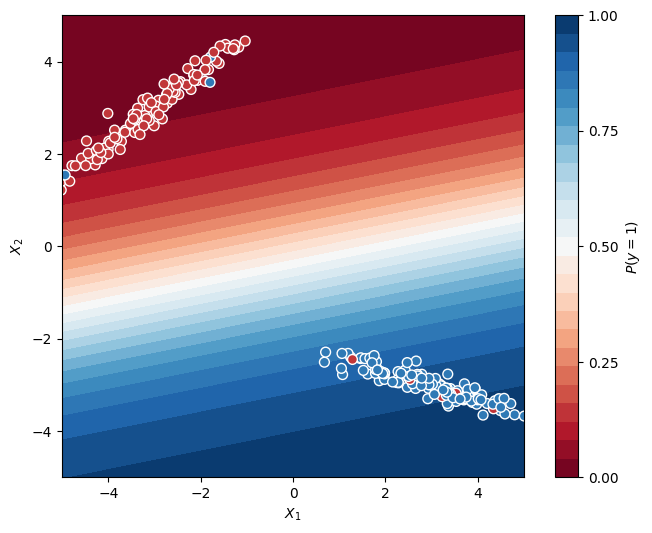

In [293]:
X, y = make_classification(n_features=2,
                           n_redundant=0,
                           n_samples=250,
                           n_classes=2,
                           n_clusters_per_class=1,
                           flip_y=0.05,
                           class_sep=3,
                           random_state=43)

clf = LogisticRegression()
clf.fit(X, y)

xx, yy = np.mgrid[-5:5:.01, -5:5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
#if needed change the line below
probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[:,0], X[:, 1], c=y, s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(aspect="equal",
       xlim=(-5, 5), ylim=(-5, 5),
       xlabel="$X_1$", ylabel="$X_2$")
